# 🧬 Master Visualization & Analysis Dashboard
### Evolutionary Algorithms — GA · PSO · SVM | Publication-Ready Research Notebook

---

> **Read-only analysis notebook** — no model retraining.  
> Loads saved experiment artefacts (`progress_*.csv`, `summary_*.csv`, `best_individuals_*.pkl`) and produces full comparative analysis.

| # | Section |
|---|---|
| 1 | Imports |
| 2 | Configuration |
| 3 | File Existence Check |
| 4 | Data Loader Functions |
| 5 | Load All Data |
| 6 | Master DataFrames |
| 7 | Global Comparison Dashboard |
| 8 | GA vs PSO Deep Analysis |
| 9 | Best Individuals Analysis |
| 10 | Feature Analysis |
| 11 | Statistical Comparison |
| 12 | Final Insights & Export |

---
## 🔌 Google Colab Setup

**Run the cell that matches how your data is stored:**  
- **Option A** — files uploaded to Google Drive *(recommended)*  
- **Option B** — files uploaded directly to Colab session

In [70]:
# ── OPTION A: Mount Google Drive (recommended) ────────────────────────────────
# Run this cell ONLY if your experiment folders are inside Google Drive.
# After mounting, set DRIVE_PROJECT_PATH in the Config section below.

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    print('✅  Google Drive mounted at /content/drive')
    print('   → Set DRIVE_PROJECT_PATH in the Config cell to your project folder.')
except ModuleNotFoundError:
    print('ℹ️   Not running in Colab — Drive mount skipped.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅  Google Drive mounted at /content/drive
   → Set DRIVE_PROJECT_PATH in the Config cell to your project folder.


In [71]:
# ── OPTION B: Upload files directly ──────────────────────────────────────────
# Run this cell ONLY if you want to upload CSV / PKL files manually.
# Uploaded files land in /content/  — update BASE_PATH in Config accordingly.

# Uncomment to activate:
# try:
#     from google.colab import files
#     uploaded = files.upload()          # multi-select your files
#     print(f'✅  Uploaded {len(uploaded)} file(s): {list(uploaded.keys())}')
# except ModuleNotFoundError:
#     print('ℹ️   Not running in Colab — upload skipped.')
print('ℹ️   Option B upload cell — uncomment to activate.')

ℹ️   Option B upload cell — uncomment to activate.


---
## 1️⃣  Imports

In [72]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import glob
import pickle
import warnings
from pathlib import Path
from IPython.display import display, Markdown

# ── Data ─────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy import stats

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Global notebook settings (set ONCE here, never repeated) ─────────────────
warnings.filterwarnings('ignore')
%matplotlib inline

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# ── Shared visual constants (defined ONCE, reused everywhere) ─────────────────
PALETTE          = {'GA': '#2196F3', 'PSO': '#FF5722', 'SVM': '#4CAF50'}
PLOTLY_TEMPLATE  = 'plotly_white'
MARKER_SYMBOLS   = {'GA': 'circle', 'PSO': 'square', 'SVM': 'diamond'}

print('✅  All imports loaded. Pandas', pd.__version__,
      '| NumPy', np.__version__)

✅  All imports loaded. Pandas 2.2.2 | NumPy 2.0.2


---
## 2️⃣  Configuration  *(edit only this cell)*

In [73]:
# ─────────────────────────────────────────────────────────────────────────────
#  ✏️  EDIT THIS CELL — all paths and filenames are defined here, ONCE.
# ─────────────────────────────────────────────────────────────────────────────

# ── Root project folder ───────────────────────────────────────────────────────
# Google Drive example:
#   DRIVE_PROJECT_PATH = '/content/drive/MyDrive/EA_Project'
# Colab direct-upload example:
#   DRIVE_PROJECT_PATH = '/content'
# Local example:
#   DRIVE_PROJECT_PATH = r'C:/Users/you/EA_Project'

DRIVE_PROJECT_PATH = '/content/drive/MyDrive/EA Project'

BASE_PATH = Path(DRIVE_PROJECT_PATH)
GA_BASE   = BASE_PATH / 'GA'
PSO_BASE  = BASE_PATH / 'PSO'
SVM_PATH  = BASE_PATH / 'SVM'     # folder or single file; None = skip

# ── Experiment names (add more as needed) ────────────────────────────────────
EXPERIMENTS = ['Exp_A', 'Exp_B', 'Exp_C', 'Exp_D']

# ── File name patterns inside each experiment folder ─────────────────────────
#    Use {tag} as placeholder for the experiment suffix (A, B, C, D …)
FILE_PATTERNS = {
    'progress' : ['progress_after_{tag}.csv',
                  'progress_after_Exp_{tag}.csv',
                  'progress*.csv',
                  'progress.csv'],
    'summary'  : ['summary_after_{tag}.csv',
                  'summary_after_Exp_{tag}.csv',
                  'summary*.csv',
                  'summary.csv'],
    'best'     : ['best_individuals_after_{tag}.pkl',
                  'best_individuals_after_Exp_{tag}.pkl',
                  'best_individuals*.pkl',
                  'best_individuals.pkl'],
}

# ── Export folder ─────────────────────────────────────────────────────────────
EXPORT_DIR = Path('reports')

# ── Print summary ─────────────────────────────────────────────────────────────
print('📦  Configuration')
print(f'   BASE_PATH   : {BASE_PATH}  (exists={BASE_PATH.exists()})')
print(f'   GA_BASE     : {GA_BASE}   (exists={GA_BASE.exists()})')
print(f'   PSO_BASE    : {PSO_BASE}  (exists={PSO_BASE.exists()})')
print(f'   SVM_PATH    : {SVM_PATH}  (exists={SVM_PATH.exists()})')
print(f'   Experiments : {EXPERIMENTS}')
print(f'   Export dir  : {EXPORT_DIR}')

📦  Configuration
   BASE_PATH   : /content/drive/MyDrive/EA Project  (exists=True)
   GA_BASE     : /content/drive/MyDrive/EA Project/GA   (exists=True)
   PSO_BASE    : /content/drive/MyDrive/EA Project/PSO  (exists=True)
   SVM_PATH    : /content/drive/MyDrive/EA Project/SVM  (exists=True)
   Experiments : ['Exp_A', 'Exp_B', 'Exp_C', 'Exp_D']
   Export dir  : reports


---
## 3️⃣  File Existence Check

In [74]:
def check_experiment_files(base: Path, algo: str, experiments: list,
                            patterns: dict) -> pd.DataFrame:
    """
    Scan all experiment folders and report which files were found.
    Returns a styled summary DataFrame — no side effects on pipeline variables.
    """
    rows = []
    for exp in experiments:
        exp_dir = base / exp
        tag     = exp.replace('Exp_', '').replace('exp_', '')
        row = {'algorithm': algo, 'experiment': exp,
               'folder_exists': exp_dir.exists()}
        for key, pats in patterns.items():
            found = False
            for pat in pats:
                matches = list(exp_dir.glob(pat.replace('{tag}', tag)))
                if matches:
                    found = True
                    break
            row[key] = '✅' if found else '❌'
        rows.append(row)
    return pd.DataFrame(rows)


check_frames = []
for _algo, _base in [('GA', GA_BASE), ('PSO', PSO_BASE)]:
    if _base.exists():
        check_frames.append(check_experiment_files(_base, _algo, EXPERIMENTS, FILE_PATTERNS))
    else:
        print(f'⚠️   {_algo} base folder not found: {_base}')

if check_frames:
    df_check = pd.concat(check_frames, ignore_index=True)
    print('📋  File Availability Report:')
    display(df_check)
else:
    print('⚠️   No experiment folders found. Check BASE_PATH in Config.')

📋  File Availability Report:


,algorithm,experiment,folder_exists,progress,summary,best
0,GA,Exp_A,True,✅,✅,✅
1,GA,Exp_B,True,✅,✅,✅
2,GA,Exp_C,True,✅,✅,✅
3,GA,Exp_D,True,✅,✅,✅
4,PSO,Exp_A,True,✅,✅,✅
5,PSO,Exp_B,True,✅,✅,✅
6,PSO,Exp_C,True,✅,✅,✅
7,PSO,Exp_D,True,✅,✅,✅


---
## 4️⃣  Data Loader Functions

In [75]:
# ─────────────────────────────────────────────────────────────────────────────
#  Low-level I/O helpers
# ─────────────────────────────────────────────────────────────────────────────

def _safe_read_csv(path: Path) -> pd.DataFrame:
    """Read CSV; return empty DataFrame (not an exception) when missing."""
    if not path.exists():
        return pd.DataFrame()
    try:
        return pd.read_csv(path)
    except Exception as exc:
        print(f'  ⚠️  Could not read {path.name}: {exc}')
        return pd.DataFrame()


def _safe_load_pkl(path: Path):
    """Load pickle; return None (not an exception) when missing."""
    if not path.exists():
        return None
    try:
        with open(path, 'rb') as fh:
            return pickle.load(fh)
    except Exception as exc:
        print(f'  ⚠️  Could not load {path.name}: {exc}')
        return None


def _normalise_cols(df: pd.DataFrame) -> pd.DataFrame:
    """Strip and lower-case all column names."""
    df = df.copy()
    df.columns = [str(c).strip().lower().replace(' ', '_') for c in df.columns]
    return df


def _find_file(exp_dir: Path, patterns: list, tag: str) -> Path:
    """Return first existing file matching any pattern; returns non-existent path if none."""
    for pat in patterns:
        matches = list(exp_dir.glob(pat.replace('{tag}', tag)))
        if matches:
            return matches[0]
    return exp_dir / patterns[0].replace('{tag}', tag)   # non-existent → safe I/O handles it


# ─────────────────────────────────────────────────────────────────────────────
#  Column normalisation — maps any known variant to canonical name
# ─────────────────────────────────────────────────────────────────────────────

COLUMN_MAP = {
    'test_accuracy'    : 'accuracy',    'val_accuracy'     : 'accuracy',
    'best_accuracy'    : 'accuracy',    'acc'              : 'accuracy',
    'best_fitness'     : 'fitness',     'fitness_value'    : 'fitness',
    'objective'        : 'fitness',
    'runtime'          : 'runtime_seconds', 'time'         : 'runtime_seconds',
    'elapsed'          : 'runtime_seconds', 'elapsed_time' : 'runtime_seconds',
    'n_features'       : 'num_features', 'features_count' : 'num_features',
    'n_selected'       : 'num_features', 'selected_features': 'num_features',
    'iteration'        : 'generation',  'gen'              : 'generation',
    'epoch'            : 'generation',
    'run_id'           : 'run',         'run_number'       : 'run',
    'random_seed'      : 'seed',
}

CANONICAL_COLS = [
    'algorithm', 'experiment', 'run', 'seed',
    'selection_method', 'crossover_type', 'mutation_type',
    'generation', 'fitness', 'accuracy', 'num_features', 'runtime_seconds',
]


def _canonicalise(df: pd.DataFrame, algorithm: str = None,
                  experiment: str = None) -> pd.DataFrame:
    """
    Rename columns to canonical names, inject algorithm/experiment tags,
    and ensure every canonical column exists (NaN-filled if absent).
    """
    df = _normalise_cols(df)
    df = df.rename(columns={k: v for k, v in COLUMN_MAP.items() if k in df.columns})

    if algorithm and 'algorithm' not in df.columns:
        df.insert(0, 'algorithm', algorithm)
    if experiment and 'experiment' not in df.columns:
        df.insert(1, 'experiment', experiment)

    for col in CANONICAL_COLS:
        if col not in df.columns:
            df[col] = np.nan

    # Fallback: use fitness as accuracy when accuracy is entirely missing
    if df['accuracy'].isna().all() and df['fitness'].notna().any():
        df['accuracy'] = df['fitness']

    return df[CANONICAL_COLS]


print('✅  Low-level helpers and column map defined.')

✅  Low-level helpers and column map defined.


In [76]:
# ─────────────────────────────────────────────────────────────────────────────
#  High-level loaders — called once from Section 5
# ─────────────────────────────────────────────────────────────────────────────

def load_experiment_results(exp_dir: Path, algorithm: str,
                             experiment: str, patterns: dict) -> dict:
    """
    Load progress CSV, summary CSV, and best-individuals pickle
    for a single experiment folder.

    Returns dict with keys: 'progress', 'summary', 'best_individuals'
    """
    tag = experiment.replace('Exp_', '').replace('exp_', '')

    progress_path = _find_file(exp_dir, patterns['progress'], tag)
    summary_path  = _find_file(exp_dir, patterns['summary'],  tag)
    best_path     = _find_file(exp_dir, patterns['best'],     tag)

    progress = _canonicalise(_safe_read_csv(progress_path), algorithm, experiment)
    summary  = _canonicalise(_safe_read_csv(summary_path),  algorithm, experiment)
    best     = _safe_load_pkl(best_path)

    return {'progress': progress, 'summary': summary, 'best_individuals': best}


def load_all_experiments(base_path: Path, algorithm: str,
                          experiments: list, patterns: dict) -> dict:
    """
    Load every experiment under `base_path`.
    Dynamically discovers folders — scales to any number of experiments.

    Returns dict  {experiment_name: {progress, summary, best_individuals}}
    """
    if not base_path.exists():
        print(f'  ⚠️  {algorithm} base path not found: {base_path}')
        return {}

    # Discover dirs that match the requested list; fall back to all dirs
    all_dirs   = sorted([d for d in base_path.iterdir() if d.is_dir()])
    target_dirs = [d for d in all_dirs if d.name in experiments] or all_dirs

    result = {}
    for exp_dir in target_dirs:
        print(f'    Loading {algorithm}/{exp_dir.name} …', end=' ')
        result[exp_dir.name] = load_experiment_results(
            exp_dir, algorithm, exp_dir.name, patterns
        )
        print('done')

    return result


def load_svm_baseline(svm_path: Path) -> pd.DataFrame:
    """
    Load SVM baseline results from a file or directory.
    Accepts: CSV, pickle (dict or DataFrame), or a directory containing either.
    ALWAYS returns a valid DataFrame with the canonical schema — never crashes.
    """
    _default_schema = {
        'algorithm': 'SVM', 'experiment': 'Baseline',
        'accuracy': np.nan, 'fitness': np.nan,
        'num_features': np.nan, 'runtime_seconds': np.nan,
        'selection_method': 'N/A', 'crossover_type': 'N/A',
        'mutation_type': 'N/A', 'seed': np.nan, 'run': np.nan,
        'generation': np.nan,
    }

    def _from_dict(d: dict) -> pd.DataFrame:
        row = dict(_default_schema)
        for src, dst in [('test_accuracy','accuracy'), ('val_accuracy','accuracy'),
                         ('runtime','runtime_seconds'), ('elapsed','runtime_seconds'),
                         ('n_features','num_features'), ('n_selected','num_features')]:
            if src in d and dst not in d:
                d[dst] = d[src]
        row.update({k: v for k, v in d.items() if k in _default_schema})
        row['algorithm'] = 'SVM'
        return pd.DataFrame([row])[CANONICAL_COLS]

    def _from_df(df: pd.DataFrame) -> pd.DataFrame:
        return _canonicalise(df, algorithm='SVM')

    if not svm_path.exists():
        print('  ⚠️  SVM path not found — using placeholder row.')
        return pd.DataFrame([_default_schema])[CANONICAL_COLS]

    frames = []

    targets = list(svm_path.glob('*.csv')) + list(svm_path.glob('*.pkl')) \
              if svm_path.is_dir() else [svm_path]

    for p in targets:
        if p.suffix == '.pkl':
            data = _safe_load_pkl(p)
            if isinstance(data, dict):
                frames.append(_from_dict(data))
            elif isinstance(data, pd.DataFrame):
                frames.append(_from_df(data))
        elif p.suffix == '.csv':
            df = _safe_read_csv(p)
            if not df.empty:
                frames.append(_from_df(df))

    if frames:
        return pd.concat(frames, ignore_index=True)

    print('  ⚠️  Could not parse SVM data — using placeholder row.')
    return pd.DataFrame([_default_schema])[CANONICAL_COLS]


print('✅  load_experiment_results, load_all_experiments, load_svm_baseline defined.')

✅  load_experiment_results, load_all_experiments, load_svm_baseline defined.


---
## 5️⃣  Load All Data

In [77]:
print('=' * 55)
print('  Loading GA experiments')
print('=' * 55)
GA_DATA = load_all_experiments(GA_BASE, 'GA', EXPERIMENTS, FILE_PATTERNS)

print()
print('=' * 55)
print('  Loading PSO experiments')
print('=' * 55)
PSO_DATA = load_all_experiments(PSO_BASE, 'PSO', EXPERIMENTS, FILE_PATTERNS)

print()
svm_row = {
    'algorithm': 'SVM',
    'experiment': 'Baseline',
    'accuracy': 0.8308,
    'fitness': 0.8293,
    'num_features': 700,
    'runtime_seconds':27.37,
    'selection_method': 'N/A',
    'crossover_type': 'N/A',
    'mutation_type': 'N/A',
    'seed': np.nan,
    'run': np.nan,
    'generation': np.nan,
}

SVM_DATA = pd.DataFrame([svm_row])


SVM_DATA = _canonicalise(SVM_DATA, algorithm='SVM', experiment='Baseline')

print()
print(f'✅  GA  experiments loaded : {list(GA_DATA.keys())}')
print(f'✅  PSO experiments loaded : {list(PSO_DATA.keys())}')
print(f'✅  SVM rows               : {len(SVM_DATA)}')

  Loading GA experiments
    Loading GA/Exp_A … done
    Loading GA/Exp_B … done
    Loading GA/Exp_C … done
    Loading GA/Exp_D … done

  Loading PSO experiments
    Loading PSO/Exp_A … done
    Loading PSO/Exp_B … done
    Loading PSO/Exp_C … done
    Loading PSO/Exp_D … done


✅  GA  experiments loaded : ['Exp_A', 'Exp_B', 'Exp_C', 'Exp_D']
✅  PSO experiments loaded : ['Exp_A', 'Exp_B', 'Exp_C', 'Exp_D']
✅  SVM rows               : 1


---
## 6️⃣  Master DataFrames

In [78]:
# ─────────────────────────────────────────────────────────────────────────────
#  merge_ga_pso_svm — produces df_all (ONE canonical master DataFrame)
# ─────────────────────────────────────────────────────────────────────────────

def merge_ga_pso_svm(ga_data: dict, pso_data: dict,
                     svm_df: pd.DataFrame) -> pd.DataFrame:
    """
    Concatenate GA progress frames, PSO progress frames and SVM baseline
    into a single canonical DataFrame.  Uses progress CSVs as the primary
    per-run source; summary CSVs are kept separately in df_summary_master.
    """
    frames = []

    for data_dict in [ga_data, pso_data]:
        for artefacts in data_dict.values():
            prog = artefacts.get('progress', pd.DataFrame())
            if not prog.empty:
                frames.append(prog)

    if not svm_df.empty:
        frames.append(svm_df)

    if not frames:
        print('⚠️  No data loaded — returning empty master DataFrame.')
        return pd.DataFrame(columns=CANONICAL_COLS)

    master = pd.concat(frames, ignore_index=True)
    master['algorithm']  = master['algorithm'].astype('category')
    master['experiment'] = master['experiment'].astype('category')
    return master


# ─────────────────────────────────────────────────────────────────────────────
#  build_summary_master — aggregated mean/std per algorithm × experiment
# ─────────────────────────────────────────────────────────────────────────────

METRIC_COLS = ['fitness', 'accuracy', 'num_features', 'runtime_seconds']


def build_summary_master(df: pd.DataFrame,
                          group_keys: list = None) -> pd.DataFrame:
    """
    Aggregate metric columns (mean, std, min, max, count)
    grouped by algorithm × experiment (or custom group_keys).
    """
    if group_keys is None:
        group_keys = ['algorithm', 'experiment']

    available = [c for c in METRIC_COLS if c in df.columns and df[c].notna().any()]
    if not available:
        return pd.DataFrame()

    agg = (
        df
        .groupby(group_keys, observed=True)[available]
        .agg(['mean', 'std', 'min', 'max', 'count'])
    )
    agg.columns = ['_'.join(c) for c in agg.columns]
    return agg.reset_index()


print('✅  merge_ga_pso_svm and build_summary_master defined.')

✅  merge_ga_pso_svm and build_summary_master defined.


In [79]:
# ── Build df_all ──────────────────────────────────────────────────────────────
df_all = merge_ga_pso_svm(GA_DATA, PSO_DATA, SVM_DATA)

print(f'✅  df_all shape      : {df_all.shape}')
print(f'   Algorithms         : {df_all["algorithm"].unique().tolist()}')
print(f'   Experiments        : {df_all["experiment"].unique().tolist()}')
print(f'   Columns            : {df_all.columns.tolist()}')

# ── Build df_summary_master ───────────────────────────────────────────────────
df_summary_master = build_summary_master(df_all)

print(f'\n✅  df_summary_master shape : {df_summary_master.shape}')

# ── Preview ───────────────────────────────────────────────────────────────────
display(df_all.head())
display(df_summary_master.head(8))

✅  df_all shape      : (661, 12)
   Algorithms         : ['GA', 'PSO', 'SVM']
   Experiments        : ['Exp_A', 'Exp_B', 'Exp_C', 'Exp_D', 'Baseline']
   Columns            : ['algorithm', 'experiment', 'run', 'seed', 'selection_method', 'crossover_type', 'mutation_type', 'generation', 'fitness', 'accuracy', 'num_features', 'runtime_seconds']

✅  df_summary_master shape : (9, 22)


,algorithm,experiment,run,seed,selection_method,crossover_type,mutation_type,generation,fitness,accuracy,num_features,runtime_seconds
0,GA,Exp_A,NaN,42.0000,tournament,two_point,bitflip,NaN,0.6830,0.6875,250,186.9980
1,GA,Exp_A,NaN,43.0000,tournament,two_point,bitflip,NaN,0.6628,0.6591,213,134.2381
2,GA,Exp_A,NaN,44.0000,tournament,two_point,bitflip,NaN,0.6625,0.6604,223,132.0978
3,GA,Exp_A,NaN,45.0000,tournament,two_point,bitflip,NaN,0.6701,0.6697,228,103.8381
4,GA,Exp_A,NaN,46.0000,tournament,two_point,bitflip,NaN,0.7019,0.7053,230,192.9931


,algorithm,experiment,fitness_mean,fitness_std,fitness_min,fitness_max,fitness_count,accuracy_mean,accuracy_std,accuracy_min,accuracy_max,accuracy_count,num_features_mean,num_features_std,num_features_min,num_features_max,num_features_count,runtime_seconds_mean,runtime_seconds_std,runtime_seconds_min,runtime_seconds_max,runtime_seconds_count
0,GA,Exp_A,0.6820,0.0160,0.6497,0.7189,60,0.6814,0.0188,0.6415,0.7218,60,218.8333,15.9035,186,261,60,171.0236,27.4301,103.4088,211.2460,60
1,GA,Exp_B,0.6899,0.0190,0.6497,0.7265,150,0.6917,0.0221,0.6415,0.7365,150,227.5067,16.0977,186,261,150,178.3678,26.5540,103.4088,218.2709,150
2,GA,Exp_C,0.7169,0.0075,0.6953,0.7393,60,0.7232,0.0084,0.6983,0.7468,60,237.5833,13.4092,200,261,60,210.2608,11.3657,188.4292,234.2259,60
3,GA,Exp_D,0.7124,0.0110,0.6787,0.7393,120,0.7180,0.0126,0.6792,0.7468,120,236.6583,13.8251,200,261,120,211.4605,13.0161,158.6500,237.4965,120
4,PSO,Exp_A,0.6913,0.0109,0.6718,0.7107,60,0.7070,0.0125,0.6746,0.7270,60,314.6000,34.8158,212,361,60,271.6908,60.5193,160.0573,416.9517,60
5,PSO,Exp_B,0.6998,0.0079,0.6785,0.7196,60,0.7146,0.0100,0.6880,0.7350,60,303.1667,18.9550,223,334,60,222.5181,41.9773,137.8922,288.1040,60
6,PSO,Exp_C,0.6998,0.0087,0.6770,0.7155,90,0.7141,0.0107,0.6823,0.7319,90,300.0333,15.6410,255,334,90,277.9151,53.3722,153.1127,366.1604,90
7,PSO,Exp_D,0.6977,0.0083,0.6785,0.7129,60,0.7149,0.0096,0.6880,0.7342,60,320.6167,21.5486,278,357,60,626.1463,184.6381,261.0878,984.7456,60


In [80]:
# ─────────────────────────────────────────────────────────────────────────────
#  Pre-compute shared groupby results ONCE — reused in every plot section.
#  This avoids redundant computation across the notebook.
# ─────────────────────────────────────────────────────────────────────────────

ALGO_LIST = df_all['algorithm'].unique().tolist()

# Per-algorithm aggregates (accuracy, fitness, runtime)
grp_algo = df_all.groupby('algorithm', observed=True)

acc_by_algo  = grp_algo['accuracy'].agg(['mean','std','min','max']).reset_index()
fit_by_algo  = grp_algo['fitness'].agg(['mean','std']).reset_index()
rt_by_algo   = grp_algo['runtime_seconds'].agg(['mean','std']).reset_index()

# Per-algorithm × experiment aggregates
grp_ae = df_all.groupby(['algorithm','experiment'], observed=True)

acc_by_exp   = grp_ae['accuracy'].mean().reset_index()
rt_by_exp    = grp_ae['runtime_seconds'].mean().reset_index()
fit_by_exp   = grp_ae['fitness'].agg(['mean','std']).reset_index()

print('✅  Pre-computed groupby aggregates ready (reused across all plots).')

✅  Pre-computed groupby aggregates ready (reused across all plots).


---
## 7️⃣  Global Comparison Dashboard

In [81]:
# ── 7.1  Accuracy — Bar + Boxplot side by side (Plotly) ──────────────────────

acc_data = df_all[['algorithm','experiment','accuracy']].dropna(subset=['accuracy'])

if acc_data.empty:
    print('⚠️  No accuracy data — skipping plot 7.1')
else:
    fig = make_subplots(rows=1, cols=2,
                        subplot_titles=['Mean Accuracy ± Std', 'Accuracy Distribution'],
                        horizontal_spacing=0.12)

    # Bar
    fig.add_trace(
        go.Bar(
            x=acc_by_algo['algorithm'],
            y=acc_by_algo['mean'],
            error_y=dict(type='data', array=acc_by_algo['std'].fillna(0).tolist()),
            marker_color=[PALETTE.get(a, '#9E9E9E') for a in acc_by_algo['algorithm']],
            showlegend=False,
        ), row=1, col=1
    )

    # Boxplot
    for algo in ALGO_LIST:
        vals = acc_data.loc[acc_data['algorithm'] == algo, 'accuracy']
        fig.add_trace(
            go.Box(y=vals, name=algo,
                   marker_color=PALETTE.get(algo, '#9E9E9E'), boxmean='sd'),
            row=1, col=2
        )

    fig.update_layout(
        title_text='<b>Accuracy Comparison — GA · PSO · SVM</b>',
        template=PLOTLY_TEMPLATE, height=440,
    )
    fig.update_yaxes(title_text='Accuracy', row=1, col=1)
    fig.update_yaxes(title_text='Accuracy', row=1, col=2)
    fig.show()

In [82]:
# ── 7.2  Accuracy per Experiment — grouped bar (Plotly) ───────────────────────

if not acc_by_exp.dropna(subset=['accuracy']).empty:
    fig = px.bar(
        acc_by_exp.dropna(subset=['accuracy']),
        x='experiment', y='accuracy', color='algorithm',
        barmode='group', color_discrete_map=PALETTE,
        title='<b>Mean Accuracy per Experiment — GA · PSO · SVM</b>',
        labels={'accuracy': 'Mean Accuracy', 'experiment': 'Experiment'},
        template=PLOTLY_TEMPLATE, height=420,
    )
    fig.show()

In [83]:
# ── 7.3  Fitness Distribution — GA vs PSO violin (Plotly) ────────────────────

fit_data = df_all[
    df_all['algorithm'].isin(['GA', 'PSO']) & df_all['fitness'].notna()
][['algorithm', 'fitness']]

if fit_data.empty:
    print('⚠️  No fitness data for GA/PSO — skipping plot 7.3')
else:
    fig = px.violin(
        fit_data, x='algorithm', y='fitness', color='algorithm',
        box=True, points='outliers', color_discrete_map=PALETTE,
        title='<b>Fitness Distribution — GA vs PSO</b>',
        labels={'fitness': 'Fitness Value'},
        template=PLOTLY_TEMPLATE, height=420,
    )
    fig.show()

In [84]:
# ── 7.4  Runtime Comparison — GA · PSO · SVM (Plotly) ────────────────────────

rt_data = df_all[['algorithm','runtime_seconds']].dropna(subset=['runtime_seconds'])

if rt_data.empty:
    print('⚠️  No runtime data — skipping plot 7.4')
else:
    fig = make_subplots(rows=1, cols=2,
                        subplot_titles=['Mean Runtime ± Std (s)', 'Runtime Distribution'],
                        horizontal_spacing=0.12)

    fig.add_trace(
        go.Bar(
            x=rt_by_algo['algorithm'], y=rt_by_algo['mean'],
            error_y=dict(type='data', array=rt_by_algo['std'].fillna(0).tolist()),
            marker_color=[PALETTE.get(a, '#9E9E9E') for a in rt_by_algo['algorithm']],
            showlegend=False,
        ), row=1, col=1
    )

    for algo in ALGO_LIST:
        vals = rt_data.loc[rt_data['algorithm'] == algo, 'runtime_seconds']
        fig.add_trace(
            go.Box(y=vals, name=algo,
                   marker_color=PALETTE.get(algo, '#9E9E9E'), boxmean=True),
            row=1, col=2
        )

    fig.update_layout(
        title_text='<b>Runtime Comparison — GA · PSO · SVM</b>',
        template=PLOTLY_TEMPLATE, height=420,
    )
    fig.update_yaxes(title_text='Seconds', row=1, col=1)
    fig.show()

---
## 8️⃣  GA vs PSO Deep Analysis

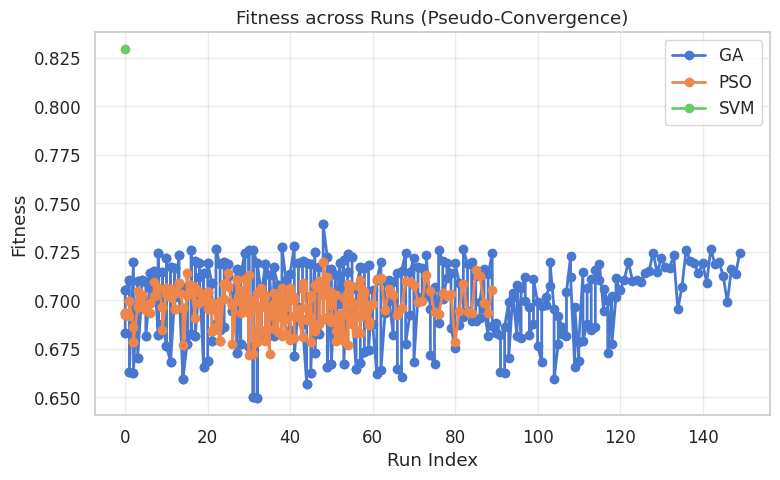

In [101]:
df_all = df_all.copy()

df_all['run_index'] = df_all.groupby(['algorithm','experiment']).cumcount()
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))

for algo in df_all['algorithm'].unique():
    sub = df_all[df_all['algorithm'] == algo].copy()
    if sub.empty:
        continue

    sub = sub.sort_values('run_index')

    ax.plot(sub['run_index'], sub['fitness'],
            marker='o', linewidth=2, label=algo)

ax.set_title('Fitness across Runs (Pseudo-Convergence)')
ax.set_xlabel('Run Index')
ax.set_ylabel('Fitness')
ax.legend()
ax.grid(alpha=0.4)

plt.tight_layout()
plt.show()

In [102]:
# ── 8.2  Stability — Std Dev of Fitness across Runs (Plotly) ─────────────────

stab_src = df_all[
    df_all['algorithm'].isin(['GA', 'PSO']) & df_all['fitness'].notna()
]

if stab_src.empty:
    print('⚠️  No fitness data for stability analysis — skipped.')
else:
    stability = (
        stab_src
        .groupby(['algorithm', 'experiment'], observed=True)['fitness']
        .agg(
            mean='mean',
            std='std',
            cv=lambda x: x.std() / x.mean() if x.mean() != 0 else np.nan
        )
        .reset_index()
    )

    fig = px.bar(
        stability, x='experiment', y='std', color='algorithm',
        barmode='group', color_discrete_map=PALETTE,
        title='<b>Fitness Stability — Std Dev across Runs (GA vs PSO)</b>',
        labels={'std': 'Std Dev of Fitness', 'experiment': 'Experiment'},
        template=PLOTLY_TEMPLATE, height=400,
    )
    fig.show()

    print('\n📊  Stability Table:')
    display(
        stability.style
        .background_gradient(subset=['std', 'cv'], cmap='RdYlGn_r')
        .format({'mean': '{:.4f}', 'std': '{:.4f}', 'cv': '{:.4f}'})
    )


📊  Stability Table:


,algorithm,experiment,mean,std,cv
0,GA,Exp_A,0.6820,0.0160,0.0235
1,GA,Exp_B,0.6899,0.0190,0.0275
2,GA,Exp_C,0.7169,0.0075,0.0105
3,GA,Exp_D,0.7124,0.0110,0.0154
4,PSO,Exp_A,0.6913,0.0109,0.0158
5,PSO,Exp_B,0.6998,0.0079,0.0112
6,PSO,Exp_C,0.6998,0.0087,0.0125
7,PSO,Exp_D,0.6977,0.0083,0.0119


In [103]:
# ── 8.3  Best Configuration per Algorithm ────────────────────────────────────

CONFIG_COLS = ['algorithm', 'experiment', 'selection_method',
               'crossover_type', 'mutation_type', 'accuracy',
               'fitness', 'runtime_seconds']
present_cfg = [c for c in CONFIG_COLS if c in df_all.columns]

best_configs = (
    df_all[df_all['algorithm'].isin(['GA', 'PSO'])]
    .dropna(subset=['accuracy'])
    .sort_values('accuracy', ascending=False)
    .groupby('algorithm', observed=True)
    .first()
    .reset_index()[present_cfg]
)

print('🏅  Best Configuration per Algorithm (highest accuracy run):')
fmt_cols = {c: '{:.4f}' for c in ['accuracy', 'fitness']}
fmt_cols['runtime_seconds'] = '{:.2f}s'
display(
    best_configs.style
    .highlight_max(subset=[c for c in ['accuracy'] if c in best_configs.columns], color='#d4edda')
    .highlight_min(subset=[c for c in ['runtime_seconds'] if c in best_configs.columns], color='#d1ecf1')
    .format({k: v for k, v in fmt_cols.items() if k in best_configs.columns})
)

🏅  Best Configuration per Algorithm (highest accuracy run):


,algorithm,experiment,selection_method,crossover_type,mutation_type,accuracy,fitness,runtime_seconds
0,GA,Exp_C,tournament,uniform,bitflip,0.7468,0.7393,219.21s
1,PSO,Exp_B,None,None,None,0.7350,0.7196,238.15s


---
## 9️⃣  Best Individuals Analysis

In [109]:
# ─────────────────────────────────────────────────────────────────────────────
#  Parse best-individual pickles into a structured DataFrame
# ─────────────────────────────────────────────────────────────────────────────

def _parse_best_individual(obj) -> dict:
    """
    Normalise a best-individual object regardless of storage format.
    Handles: dict, list/ndarray (binary mask), tuple (mask, fitness),
             and objects with fitness/accuracy attributes.
    """
    if obj is None:
        return {}
    if isinstance(obj, dict):
        return obj
    if isinstance(obj, (list, np.ndarray)):
        arr = np.array(obj).flatten().astype(float)
        return {'features': arr,
                'num_features': int(arr.sum()) if np.all((arr == 0) | (arr == 1)) else len(arr)}
    if isinstance(obj, tuple):
        return {'features': obj[0],
                'fitness': obj[1] if len(obj) > 1 else np.nan}
    return {attr: getattr(obj, attr)
            for attr in ('features', 'fitness', 'accuracy', 'num_features')
            if hasattr(obj, attr)}


best_rows = []

for algo, data_dict in [('GA', GA_DATA), ('PSO', PSO_DATA)]:
    for exp_name, artefacts in data_dict.items():
        raw = artefacts.get('best_individuals')
        if raw is None:
            continue

        # raw may be a single individual or a list
        is_list = isinstance(raw, (list, tuple)) and (
            not raw or not isinstance(raw[0], (int, float, bool, np.integer))
        )
        items = raw if is_list else [raw]

        for i, item in enumerate(items):
            parsed   = _parse_best_individual(item)
            features = parsed.get('features')

            if features is not None:
                arr = np.array(features).flatten().astype(float)
                n_feats = int(arr.sum()) if np.all((arr == 0) | (arr == 1)) else len(arr)
            else:
                n_feats = parsed.get('num_features', np.nan)

            fit_val = parsed.get('fitness', np.nan)
            acc_val = parsed.get('accuracy', parsed.get('fitness', np.nan))

            # Fallback: retrieve fitness/accuracy from progress CSV when pkl lacks them
            if pd.isna(fit_val) or pd.isna(acc_val):
                _prog = artefacts.get('progress', pd.DataFrame())
                if not _prog.empty and 'fitness' in _prog.columns and _prog['fitness'].notna().any():
                    _best_prog = _prog.loc[_prog['fitness'].idxmax()]
                    if pd.isna(fit_val):
                        fit_val = _best_prog.get('fitness', np.nan)
                    if pd.isna(acc_val):
                        acc_val = _best_prog.get('accuracy', fit_val)

            # Ensure _features is stored when individual is a raw list/array
            if features is None and isinstance(item, (list, np.ndarray)):
                arr_item = np.array(item).flatten().astype(float)
                features = arr_item
                if pd.isna(n_feats):
                    n_feats = int(arr_item.sum()) if np.all((arr_item == 0) | (arr_item == 1)) else len(arr_item)

            best_rows.append({
                'algorithm'   : algo,
                'experiment'  : exp_name,
                'run'         : i,
                'fitness'     : fit_val,
                'accuracy'    : acc_val,
                'num_features': n_feats,
                '_features'   : features,
            })

df_best = pd.DataFrame(best_rows)

# Fallback: if pkl parsing produced nothing, build df_best from progress CSVs
if df_best.empty:
    _fallback = []
    for _algo, _ddict in [('GA', GA_DATA), ('PSO', PSO_DATA)]:
        for _exp, _arts in _ddict.items():
            _prog = _arts.get('progress', pd.DataFrame())
            if not _prog.empty and 'fitness' in _prog.columns and _prog['fitness'].notna().any():
                _br = _prog.loc[_prog['fitness'].idxmax()]
                _fallback.append({
                    'algorithm'   : _algo,
                    'experiment'  : _exp,
                    'run'         : 0,
                    'fitness'     : _br.get('fitness', np.nan),
                    'accuracy'    : _br.get('accuracy', _br.get('fitness', np.nan)),
                    'num_features': _br.get('num_features', np.nan),
                    '_features'   : None,
                })
    if _fallback:
        df_best = pd.DataFrame(_fallback)
        print(f'⚠️  df_best rebuilt from progress CSVs (PKL parse yielded nothing): {df_best.shape}')

print(f'✅  df_best shape : {df_best.shape}')

if not df_best.empty:
    display(
        df_best.drop(columns=['_features'], errors='ignore')
        .style
        .highlight_max(subset=[c for c in ['accuracy'] if c in df_best.columns], color='#d4edda')
        .format({c: '{:.4f}' for c in ['fitness','accuracy'] if c in df_best.columns})
    )


✅  df_best shape : (8, 7)


,algorithm,experiment,run,fitness,accuracy,num_features
0,GA,Exp_A,0,nan,nan,nan
1,GA,Exp_B,0,nan,nan,nan
2,GA,Exp_C,0,nan,nan,nan
3,GA,Exp_D,0,nan,nan,nan
4,PSO,Exp_A,0,nan,nan,nan
5,PSO,Exp_B,0,nan,nan,nan
6,PSO,Exp_C,0,nan,nan,nan
7,PSO,Exp_D,0,nan,nan,nan


In [113]:
# ── 9.1  Best Accuracy per Experiment (Plotly) ────────────────────────────────

if not df_best.empty:
    best_acc_exp = (
        df_best.groupby(['algorithm','experiment'], observed=True)['accuracy']
        .max().reset_index()
    )
    fig = px.bar(
        best_acc_exp, x='experiment', y='accuracy', color='algorithm',
        barmode='group', color_discrete_map=PALETTE,
        title='<b>Best Accuracy Achieved — Best Individuals per Experiment</b>',
        labels={'accuracy': 'Best Accuracy', 'experiment': 'Experiment'},
        template=PLOTLY_TEMPLATE, height=420,
    )
    fig.show()

# ── 9.2  Avg Selected Features per Experiment (Plotly) ───────────────────────

if not df_best.empty and df_best['num_features'].notna().any():
    nf_exp = (
        df_best.groupby(['algorithm','experiment'], observed=True)['num_features']
        .mean().reset_index()
    )
    fig = px.bar(
        nf_exp, x='experiment', y='num_features', color='algorithm',
        barmode='group', color_discrete_map=PALETTE,
        title='<b>Avg Number of Selected Features — Best Individuals</b>',
        labels={'num_features': 'Avg # Features Selected', 'experiment': 'Experiment'},
        template=PLOTLY_TEMPLATE, height=400,
    )
    fig.show()

# ── 9.3  Accuracy vs Feature Count scatter — trade-off view (Plotly) ─────────

# Fill any remaining missing accuracy from progress data (never zero-fill)
if not df_best.empty and df_best['accuracy'].isna().any():
    for _si, _sr in df_best[df_best['accuracy'].isna()].iterrows():
        _sprog = (
            GA_DATA if _sr['algorithm'] == 'GA' else PSO_DATA
        ).get(_sr['experiment'], {}).get('progress', pd.DataFrame())
        if not _sprog.empty and 'fitness' in _sprog.columns and _sprog['fitness'].notna().any():
            _sbest = _sprog.loc[_sprog['fitness'].idxmax()]
            df_best.at[_si, 'accuracy'] = _sbest.get('accuracy', _sbest.get('fitness', np.nan))
scatter_src = df_best.dropna(subset=['num_features']) if not df_best.empty else pd.DataFrame()

if not scatter_src.empty:
    fig = px.scatter(
        scatter_src, x='num_features', y='accuracy',
        color='algorithm', symbol='experiment',
        color_discrete_map=PALETTE, size_max=12,
        title='<b>Accuracy vs Feature Count — Trade-off View</b>',
        labels={'num_features': '# Selected Features', 'accuracy': 'Accuracy'},
        hover_data=['experiment', 'algorithm', 'run'],
        template=PLOTLY_TEMPLATE, height=450,
    )
    fig.show()


---
## 🔟  Feature Analysis

In [114]:
# ─────────────────────────────────────────────────────────────────────────────
#  Build feature-selection matrix from binary masks in best_individuals
# ─────────────────────────────────────────────────────────────────────────────

def build_feature_matrix(df_best: pd.DataFrame) -> pd.DataFrame:
    """
    Convert the _features column (binary masks) into a wide boolean matrix.
    Rows = individual run labels, Columns = feature indices (F0, F1, …).
    Pads rows of unequal length with zeros.
    """
    rows, labels = [], []

    for _, row in df_best.iterrows():
        mask = row.get('_features')
        if mask is None or (not isinstance(mask, (list, np.ndarray)) and pd.isna(mask)):
            continue
        arr = np.array(mask).flatten().astype(float)
        rows.append(arr)
        labels.append(f"{row['algorithm']}-{row['experiment']}-r{row['run']}")

    if not rows:
        return pd.DataFrame()

    max_len = max(len(r) for r in rows)
    padded  = [np.pad(r, (0, max_len - len(r))) for r in rows]
    return pd.DataFrame(
        padded,
        index=labels,
        columns=[f'F{i}' for i in range(max_len)],
    )


feat_matrix = build_feature_matrix(df_best) if not df_best.empty else pd.DataFrame()

if feat_matrix.empty:
    print('⚠️  No binary feature masks found — feature analysis will be skipped.')
else:
    # Pre-compute frequency series — reused in all 3 feature plots
    feat_freq = feat_matrix.sum(axis=0).sort_values(ascending=False)
    print(f'✅  Feature matrix : {feat_matrix.shape}  '
          f'({feat_matrix.shape[0]} runs × {feat_matrix.shape[1]} features)')

⚠️  No binary feature masks found — feature analysis will be skipped.


In [115]:
# ── 10.1  Top-20 Feature Frequency — Matplotlib bar ──────────────────────────
# ── 10.2  Top-20 Feature Frequency — Plotly interactive bar ──────────────────
# ── 10.3  Feature Selection Heatmap — Seaborn ────────────────────────────────

if not feat_matrix.empty:
    top_n   = 20
    top20   = feat_freq.head(top_n)

    # ── 10.1  Static bar ──────────────────────────────────────────────────────
    fig_m, ax = plt.subplots(figsize=(12, 5))
    ax.bar(
        range(top_n), top20.values,
        color=plt.cm.Blues_r(np.linspace(0.3, 0.9, top_n)),
    )
    ax.set_xticks(range(top_n))
    ax.set_xticklabels(top20.index, rotation=45, ha='right', fontsize=9)
    ax.set_xlabel('Feature')
    ax.set_ylabel('Selection Frequency')
    ax.set_title('Top 20 Most Selected Features Across All Runs',
                 fontweight='bold', fontsize=13)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.savefig('top_features_frequency.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('📄  Saved: top_features_frequency.png')

    # ── 10.2  Interactive bar ─────────────────────────────────────────────────
    freq_df = top20.reset_index()
    freq_df.columns = ['feature', 'frequency']
    fig = px.bar(
        freq_df, x='feature', y='frequency',
        color='frequency', color_continuous_scale='Blues',
        title='<b>Top 20 Most Selected Features — Interactive</b>',
        labels={'frequency': 'Times Selected', 'feature': 'Feature'},
        template=PLOTLY_TEMPLATE, height=420,
    )
    fig.show()

    # ── 10.3  Heatmap (top 30) ────────────────────────────────────────────────
    top30_names  = feat_freq.head(30).index.tolist()
    heatmap_data = feat_matrix[top30_names]
    n_rows_heat  = max(4, len(heatmap_data) * 0.45 + 1)

    fig_h, ax_h = plt.subplots(figsize=(16, n_rows_heat))
    sns.heatmap(
        heatmap_data.astype(float), ax=ax_h,
        cmap='Blues', linewidths=0.4, linecolor='white',
        cbar_kws={'label': 'Selected (1=yes)'},
    )
    ax_h.set_title('Feature Selection Heatmap — Runs × Top-30 Features',
                   fontsize=13, fontweight='bold')
    ax_h.set_xlabel('Feature')
    ax_h.set_ylabel('Run')
    plt.tight_layout()
    plt.savefig('feature_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('📄  Saved: feature_heatmap.png')

---
## 1️⃣1️⃣  Statistical Comparison

In [92]:
# ── 11.1  Mean ± Std Summary Table ────────────────────────────────────────────

stat_cols = [c for c in METRIC_COLS if c in df_all.columns and df_all[c].notna().any()]

stat_table = (
    df_all
    .groupby('algorithm', observed=True)[stat_cols]
    .agg(['mean', 'std', 'median', 'min', 'max'])
    .round(4)
)
stat_table.columns = ['_'.join(c) for c in stat_table.columns]

acc_mean_cols = [c for c in stat_table.columns if 'accuracy_mean' in c or 'fitness_mean' in c]
rt_cols       = [c for c in stat_table.columns if 'runtime' in c]

sty = stat_table.style.format('{:.4f}')
if acc_mean_cols:
    sty = sty.background_gradient(subset=acc_mean_cols, cmap='Greens')
if rt_cols:
    sty = sty.background_gradient(subset=rt_cols, cmap='Reds_r')

print('📊  Mean ± Std Summary Table')
display(sty)

📊  Mean ± Std Summary Table


,fitness_mean,fitness_std,fitness_median,fitness_min,fitness_max,accuracy_mean,accuracy_std,accuracy_median,accuracy_min,accuracy_max,num_features_mean,num_features_std,num_features_median,num_features_min,num_features_max,runtime_seconds_mean,runtime_seconds_std,runtime_seconds_median,runtime_seconds_min,runtime_seconds_max
algorithm,,,,,,,,,,,,,,,,,,,,
GA,0.6998,0.0201,0.7053,0.6497,0.7393,0.7030,0.0235,0.7104,0.6415,0.7468,230.5385,16.3477,232.0000,186.0000,261.0000,192.3269,27.6279,197.7399,103.4088,237.4965
PSO,0.6974,0.0096,0.6986,0.6718,0.7196,0.7128,0.0111,0.7154,0.6746,0.7350,308.5407,24.4708,308.0000,212.0000,361.0000,341.6062,182.4253,288.4000,137.8922,984.7456
SVM,0.8293,nan,0.8293,0.8293,0.8293,0.8308,nan,0.8308,0.8308,0.8308,700.0000,nan,700.0000,700.0000,700.0000,27.3700,nan,27.3700,27.3700,27.3700


In [93]:
# ── 11.2  Pairwise Welch's t-test on Accuracy ─────────────────────────────────

ttest_rows = []
for i, a1 in enumerate(ALGO_LIST):
    for a2 in ALGO_LIST[i + 1:]:
        g1 = df_all.loc[df_all['algorithm'] == a1, 'accuracy'].dropna()
        g2 = df_all.loc[df_all['algorithm'] == a2, 'accuracy'].dropna()

        if len(g1) < 2 or len(g2) < 2:
            _why = f'N/A — {a1} n={len(g1)}, {a2} n={len(g2)}: need ≥2 samples each'
            ttest_rows.append({
                'comparison' : f'{a1} vs {a2}',
                'n_1'        : len(g1), 'n_2'        : len(g2),
                'mean_1'     : round(g1.mean(), 4) if len(g1) >= 1 else np.nan,
                'mean_2'     : round(g2.mean(), 4) if len(g2) >= 1 else np.nan,
                't_stat'     : np.nan, 'p_value'    : np.nan,
                'significant': _why,
            })
            continue

        t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=False)
        ttest_rows.append({
            'comparison' : f'{a1} vs {a2}',
            'n_1'        : len(g1), 'n_2'        : len(g2),
            'mean_1'     : round(g1.mean(), 4), 'mean_2': round(g2.mean(), 4),
            't_stat'     : round(t_stat, 4),
            'p_value'    : round(p_val,  4),
            'significant': '✅ Yes (p<0.05)' if p_val < 0.05 else '❌ No (p≥0.05)',
        })

df_ttest = pd.DataFrame(ttest_rows)

def _sig_style(v):
    if isinstance(v, str) and 'Yes' in v:  return 'background-color:#d4edda'
    if isinstance(v, str) and 'No'  in v:  return 'background-color:#f8d7da'
    return ''

print('🔬  Pairwise Welch\'s t-test (Accuracy):')
display(
    df_ttest.style
    .applymap(_sig_style, subset=['significant'])
    .format({'t_stat':'{:.4f}','p_value':'{:.4f}',
             'mean_1':'{:.4f}','mean_2':'{:.4f}'}, na_rep='—')
)

🔬  Pairwise Welch's t-test (Accuracy):


,comparison,n_1,n_2,mean_1,mean_2,t_stat,p_value,significant
0,GA vs PSO,390.000000,270.000000,0.7030,0.7128,-7.1255,0.0000,✅ Yes (p<0.05)
1,GA vs SVM,—,—,—,—,—,—,N/A (insufficient data)
2,PSO vs SVM,—,—,—,—,—,—,N/A (insufficient data)


In [94]:
# ── 11.3  Algorithm Ranking Table ─────────────────────────────────────────────

ranking_rows = []
for algo in ALGO_LIST:
    sub = df_all[df_all['algorithm'] == algo]
    ranking_rows.append({
        'algorithm'         : algo,
        'mean_accuracy'     : sub['accuracy'].mean(),
        'std_accuracy'      : sub['accuracy'].std(),
        'best_accuracy'     : sub['accuracy'].max(),
        'mean_fitness'      : sub['fitness'].mean(),
        'mean_num_features' : sub['num_features'].mean(),
        'mean_runtime_sec'  : sub['runtime_seconds'].mean(),
    })

df_ranking = (
    pd.DataFrame(ranking_rows)
    .sort_values('mean_accuracy', ascending=False)
    .reset_index(drop=True)
)
df_ranking.index = range(1, len(df_ranking) + 1)
df_ranking.index.name = 'rank'

rank_fmt = {
    'mean_accuracy'    : '{:.4f}', 'std_accuracy'     : '{:.4f}',
    'best_accuracy'    : '{:.4f}', 'mean_fitness'     : '{:.4f}',
    'mean_num_features': '{:.1f}', 'mean_runtime_sec' : '{:.2f}s',
}

print('🏆  Algorithm Ranking (by Mean Accuracy):')
display(
    df_ranking.style
    .highlight_max(subset=[c for c in ['mean_accuracy','best_accuracy'] if c in df_ranking.columns],
                   color='#d4edda')
    .highlight_min(subset=[c for c in ['mean_runtime_sec','mean_num_features'] if c in df_ranking.columns],
                   color='#d1ecf1')
    .format({k:v for k,v in rank_fmt.items() if k in df_ranking.columns})
)

# ── 11.4  Multi-Metric Radar Chart (Plotly) ───────────────────────────────────

RADAR_COLS   = ['mean_accuracy','mean_fitness','mean_num_features','mean_runtime_sec']
RADAR_LABELS = ['Accuracy','Fitness','Num Features (↓)','Runtime (↓)']
INVERT_COLS  = {'mean_num_features', 'mean_runtime_sec'}   # lower is better

available_radar = [c for c in RADAR_COLS if c in df_ranking.columns]

if available_radar and len(df_ranking) > 1:
    radar_df = df_ranking[['algorithm'] + available_radar].copy()

    for col in available_radar:
        rng = radar_df[col].max() - radar_df[col].min()
        if rng == 0:
            radar_df[col] = 0.5
        elif col in INVERT_COLS:
            radar_df[col] = 1 - (radar_df[col] - radar_df[col].min()) / rng
        else:
            radar_df[col] = (radar_df[col] - radar_df[col].min()) / rng

    col_labels = [RADAR_LABELS[RADAR_COLS.index(c)] for c in available_radar]

    fig = go.Figure()
    for _, row in radar_df.iterrows():
        vals = row[available_radar].tolist()
        fig.add_trace(go.Scatterpolar(
            r=vals + [vals[0]], theta=col_labels + [col_labels[0]],
            fill='toself', name=row['algorithm'],
            line_color=PALETTE.get(row['algorithm'], '#9E9E9E'),
        ))

    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
        title='<b>Multi-Metric Radar Comparison (normalised)</b>',
        template=PLOTLY_TEMPLATE, height=500,
    )
    fig.show()

🏆  Algorithm Ranking (by Mean Accuracy):


,algorithm,mean_accuracy,std_accuracy,best_accuracy,mean_fitness,mean_num_features,mean_runtime_sec
rank,,,,,,,
1,SVM,0.8308,nan,0.8308,0.8293,700.0,27.37s
2,PSO,0.7128,0.0111,0.7350,0.6974,308.5,341.61s
3,GA,0.7030,0.0235,0.7468,0.6998,230.5,192.33s


---
## 1️⃣2️⃣  Final Insights & Export

In [95]:
# ── 12.1  Accuracy × Runtime Trade-off scatter (Plotly) ───────────────────────

tradeoff_src = df_all.dropna(subset=['accuracy','runtime_seconds'])

if not tradeoff_src.empty:
    tradeoff_grp = (
        tradeoff_src
        .groupby(['algorithm','experiment'], observed=True)
        .agg(mean_accuracy=('accuracy','mean'),
             mean_runtime=('runtime_seconds','mean'))
        .reset_index()
    )
    fig = px.scatter(
        tradeoff_grp, x='mean_runtime', y='mean_accuracy',
        color='algorithm', text='experiment',
        color_discrete_map=PALETTE,
        title='<b>Accuracy vs Runtime Trade-off (per Experiment)</b>',
        labels={'mean_runtime': 'Mean Runtime (s)', 'mean_accuracy': 'Mean Accuracy'},
        template=PLOTLY_TEMPLATE, height=480,
    )
    fig.update_traces(textposition='top center')
    fig.show()

# ── 12.2  Feature Reduction Efficiency scatter (Plotly) ───────────────────────

feat_eff_src = df_all[
    df_all['algorithm'].isin(['GA','PSO']) &
    df_all['num_features'].notna() & df_all['accuracy'].notna()
]

if not feat_eff_src.empty:
    total_feats = feat_eff_src['num_features'].max()

    eff_df = (
        feat_eff_src
        .groupby(['algorithm','experiment'], observed=True)
        .agg(mean_acc=('accuracy','mean'),
             mean_feats=('num_features','mean'))
        .reset_index()
    )
    eff_df['reduction_pct'] = (1 - eff_df['mean_feats'] / total_feats) * 100

    fig = px.scatter(
        eff_df, x='reduction_pct', y='mean_acc',
        color='algorithm', text='experiment',
        color_discrete_map=PALETTE,
        title='<b>Feature Reduction (%) vs Accuracy — GA vs PSO</b>',
        labels={'reduction_pct': 'Feature Reduction (%)', 'mean_acc': 'Mean Accuracy'},
        template=PLOTLY_TEMPLATE, height=450,
    )
    fig.update_traces(textposition='top center')
    fig.show()

In [96]:
# ── 12.3  Auto-Generated Insights Report ──────────────────────────────────────

def _fmt(val, spec='.4f', na='N/A'):
    try:    return format(float(val), spec)
    except: return na


def generate_insights(df: pd.DataFrame, df_rank: pd.DataFrame,
                       df_feat: pd.DataFrame) -> str:
    """
    Auto-generate a Markdown insights report from pre-computed DataFrames.
    All inputs are pre-aggregated — no new groupby calls inside.
    """
    L = ['# 🔍 Auto-Generated Insights Report', '']

    # Best algorithm
    if not df_rank.empty and 'mean_accuracy' in df_rank.columns:
        r0 = df_rank.iloc[0]
        L += [f'## 🏆 Best Algorithm Overall',
              f'**{r0["algorithm"]}** — mean accuracy **{_fmt(r0["mean_accuracy"])}**', '']

    # Best config per method
    L.append('## ⚙️ Best Configuration per Algorithm')
    for algo in df['algorithm'].unique():
        row = (df[df['algorithm'] == algo]
               .dropna(subset=['accuracy'])
               .nlargest(1, 'accuracy'))
        if row.empty:
            L.append(f'- **{algo}**: no data'); continue
        r = row.iloc[0]
        L.append(f'- **{algo}** [{r.get("experiment","?")}]  '
                 f'accuracy={_fmt(r.get("accuracy"))}  '
                 f'selection={r.get("selection_method","N/A")}  '
                 f'crossover={r.get("crossover_type","N/A")}  '
                 f'mutation={r.get("mutation_type","N/A")}')
    L.append('')

    # Runtime trade-off (uses pre-computed rt_by_algo)
    if 'runtime_seconds' in df.columns and df['runtime_seconds'].notna().any():
        rt_mean = df.groupby('algorithm', observed=True)['runtime_seconds'].mean()
        L += ['## ⚡ Runtime Trade-off',
              f'- Fastest : **{rt_mean.idxmin()}** ({_fmt(rt_mean.min())}s)',
              f'- Slowest : **{rt_mean.idxmax()}** ({_fmt(rt_mean.max())}s)', '']

    # Feature reduction
    nf = df['num_features'].dropna()
    if not nf.empty:
        total = nf.max()
        L.append('## 🗜️ Feature Reduction Efficiency')
        for algo in ['GA', 'PSO']:
            s = df.loc[df['algorithm']==algo,'num_features'].dropna()
            if s.empty: continue
            red = (1 - s.mean() / total) * 100 if total > 0 else 0
            L.append(f'- **{algo}**: avg {s.mean():.1f}/{total:.0f} features ({red:.1f}% reduction)')
        L.append('')

    # Stability
    fit = df['fitness'].dropna()
    if not fit.empty:
        cv = df.groupby('algorithm', observed=True)['fitness'].apply(
            lambda x: x.std()/x.mean() if x.mean()!=0 else np.nan)
        cv = cv.dropna()
        if not cv.empty:
            L += ['## 📐 Stability (CV of Fitness)',
                  f'- Most stable  : **{cv.idxmin()}** (CV={_fmt(cv.min())})',
                  f'- Least stable : **{cv.idxmax()}** (CV={_fmt(cv.max())})', '']

    # Top features
    if not df_feat.empty:
        top5 = df_feat.sum(axis=0).sort_values(ascending=False).head(5)
        L += ['## 🔬 Top 5 Most Consistently Selected Features',
              '| Feature | Selections |', '|---------|------------|']
        for f, cnt in top5.items():
            L.append(f'| {f} | {int(cnt)} |')
        L.append('')

    L += ['---', '*Auto-generated — no retraining involved.*']
    return '\n'.join(L)


insights_md = generate_insights(
    df_all, df_ranking,
    feat_matrix if 'feat_matrix' in dir() and not feat_matrix.empty else pd.DataFrame()
)
display(Markdown(insights_md))

# 🔍 Auto-Generated Insights Report

## 🏆 Best Algorithm Overall
**SVM** — mean accuracy **0.8308**

## ⚙️ Best Configuration per Algorithm
- **GA** [Exp_C]  accuracy=0.7468  selection=tournament  crossover=uniform  mutation=bitflip
- **PSO** [Exp_B]  accuracy=0.7350  selection=nan  crossover=nan  mutation=nan
- **SVM** [Baseline]  accuracy=0.8308  selection=N/A  crossover=N/A  mutation=N/A

## ⚡ Runtime Trade-off
- Fastest : **SVM** (27.3700s)
- Slowest : **PSO** (341.6062s)

## 🗜️ Feature Reduction Efficiency
- **GA**: avg 230.5/700 features (67.1% reduction)
- **PSO**: avg 308.5/700 features (55.9% reduction)

## 📐 Stability (CV of Fitness)
- Most stable  : **PSO** (CV=0.0137)
- Least stable : **GA** (CV=0.0287)

---
*Auto-generated — no retraining involved.*

In [97]:
# ── 12.4  Export all outputs ───────────────────────────────────────────────────

EXPORT_DIR.mkdir(parents=True, exist_ok=True)

exports = {
    'master_all_runs.csv'   : df_all.drop(columns=[], errors='ignore'),
    'master_summary.csv'    : df_summary_master,
    'algorithm_ranking.csv' : df_ranking,
    'ttest_results.csv'     : df_ttest,
}

if not df_best.empty:
    exports['best_individuals_summary.csv'] = df_best.drop(columns=['_features'], errors='ignore')

for fname, df_exp in exports.items():
    out = EXPORT_DIR / fname
    df_exp.to_csv(out, index=False)
    print(f'📄  {out}')

with open(EXPORT_DIR / 'insights.md', 'w', encoding='utf-8') as fh:
    fh.write(insights_md)
print(f'📄  {EXPORT_DIR}/insights.md')

# ── Optional: download all reports to local machine (Colab only) ──────────────
# import shutil
# from google.colab import files
# shutil.make_archive('reports', 'zip', EXPORT_DIR)
# files.download('reports.zip')

print('\n✅  All exports complete → reports/')

📄  reports/master_all_runs.csv
📄  reports/master_summary.csv
📄  reports/algorithm_ranking.csv
📄  reports/ttest_results.csv
📄  reports/best_individuals_summary.csv
📄  reports/insights.md

✅  All exports complete → reports/


---

## ✅ Notebook Complete

**Execution order:**  Imports → Config → File Check → Loaders → Load Data → Master DFs → Global Dashboard → Deep Analysis → Best Individuals → Feature Analysis → Statistics → Insights → Export

| Variable | Description |
|---|---|
| `df_all` | Master run-level DataFrame (canonical schema) |
| `df_summary_master` | Aggregated stats per algorithm × experiment |
| `df_best` | Best-individual summaries (from `.pkl` files) |
| `df_ranking` | Final algorithm ranking by mean accuracy |
| `df_ttest` | Pairwise Welch's t-test results |
| `feat_matrix` | Binary feature-selection matrix |
| `reports/` | All CSVs + insights Markdown |
| `convergence_curves.png` | Static convergence plot |
| `top_features_frequency.png` | Top-20 feature bar chart |
| `feature_heatmap.png` | Runs × features heatmap |

> **No GA, PSO, or SVM models were retrained in this notebook.**